# P2 

## Importar bibliotecas

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly

## EDA e Limpeza de Dados
### Carregar Dataframe

In [2]:
DATASET_FILE_PATH = "PTD_level_dataset.xlsx"
df = pd.read_excel(DATASET_FILE_PATH)
df.head()


,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  object 
 1   Concelho                   72027 non-null  object 
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  object 
 4   Coordenadas Geográficas    72027 non-null  object 
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  object 
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total                 72027 non-null  float64
 13  P_IP_Inef                  72027 non-null  flo

#### Resumo
- Tamanho: ~72.000 registos; mix de variáveis categóricas, inteiras e decimais.

- Nulos: Pot_Contratada_kVA, Pot_Geracao_kW, D_PTD, D_PTD_LED, Geracao_per_Cliente,Util_Decimal, PFolga_PTD; 

- Dependências: variáveis derivadas dependem de outras (PContratada_per_Cliente ← Pot_Contratada_kVA, Geracao_per_Cliente ← Pot_Geracao_kW).

- Oportunidades: analisar potência por território, concentração de clientes, ineficiência e diferenças LED/distritos.

#### Próximos Passos

- Tratar nulos: avaliar caso a caso (imputar / manter / remover).
- Verificar derivadas: confirmar fórmulas e origem dos campos calculados.
- Converter campos: percentagens → numérico; coordenadas → lat/lon.
- Análises: agregações por concelho/distrito, mapas e modelos simples se for preciso.

### Variáveis categóricas

In [4]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Columns: \n",  categorical_columns)

Categorical Columns: 
 ['Distrito', 'Concelho', 'Código de Instalação', 'Coordenadas Geográficas', 'Tipo Construtivo', 'Nível de Utilização [%]']


In [5]:
# Unique values for each categorical column
print("Valores únicos de variáveis categóricas")
for column in categorical_columns:
    unique_vals = df[column].unique()
    
    print(f"\n\n{column} ({len(unique_vals)} valores únicos):\n {unique_vals}")

Valores únicos de variáveis categóricas


Distrito (18 valores únicos):
 ['Porto' 'Santarém' 'Setúbal' 'Lisboa' 'Portalegre' 'Aveiro' 'Viseu'
 'Beja' 'Braga' 'Bragança' 'Castelo Branco' 'Coimbra' 'Évora' 'Faro'
 'Guarda' 'Leiria' 'Viana do Castelo' 'Vila Real']


Concelho (278 valores únicos):
 ['Marco de Canaveses' 'Matosinhos' 'Paços de Ferreira' 'Paredes'
 'Penafiel' 'Porto' 'Póvoa de Varzim' 'Santo Tirso' 'Valongo'
 'Vila do Conde' 'Vila Nova de Gaia' 'Trofa' 'Abrantes' 'Alcanena'
 'Almeirim' 'Alpiarça' 'Benavente' 'Cartaxo' 'Chamusca' 'Constância'
 'Coruche' 'Entroncamento' 'Ferreira do Zêzere' 'Golegã' 'Mação'
 'Rio Maior' 'Salvaterra de Magos' 'Santarém' 'Sardoal' 'Tomar'
 'Torres Novas' 'Vila Nova da Barquinha' 'Alcácer do Sal' 'Ourém'
 'Alcochete' 'Almada' 'Lisboa' 'Loures' 'Lourinhã' 'Mafra' 'Oeiras'
 'Sintra' 'Sobral de Monte Agraço' 'Torres Vedras' 'Vila Franca de Xira'
 'Amadora' 'Odivelas' 'Alter do Chão' 'Arronches' 'Avis' 'Campo Maior'
 'Castelo de Vide' 'Crato' 'Elvas'

- Tipos textuais **Único**: Código de Instalação (ID) pode ser utilizado como index; 
- Tipos textuais: Coordenadas Geográficas precisa de parsing (lat/lon); 
- Nível de Utilização [%] tem “%” N/D e tem de ser tratado.

In [6]:
# Set index
df.set_index("Código de Instalação")

,Distrito,Concelho,CodDistritoConcelho,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
Código de Instalação,,,,,,,,,,,,,,,,,,,,,
1307D2012500,Porto,Marco de Canaveses,1307,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,NaN,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.280
1307D2012900,Porto,Marco de Canaveses,1307,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,NaN,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.300
1307D2013100,Porto,Marco de Canaveses,1307,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,NaN,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.300
1307D2013800,Porto,Marco de Canaveses,1307,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,NaN,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.000
1307D2015100,Porto,Marco de Canaveses,1307,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,NaN,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503D2064600,Setúbal,Almada,1503,"38.5806660461765, -9.16363960352142",400,Cabine baixa em edifício próprio,400,92308.0,51,NaN,...,4.346658,2.825328,140.505328,7.843137,1809.960784,NaN,0.392157,40%-59%,0.59,150.880
1503D2064800,Setúbal,Almada,1503,"38.5833743026177, -9.16740821302415",250,Cabine baixa em edifício próprio,250,143175.0,238,NaN,...,4.346658,2.825328,-8.074672,1.050420,601.575630,NaN,0.084034,80%-99%,0.99,2.300
1503D2066100,Setúbal,Almada,1503,"38.6657098751253, -9.19802580740044",400,Cabine baixa em edifício próprio,400,122361.0,207,NaN,...,4.346658,2.825328,140.505328,1.932367,591.115942,NaN,0.096618,40%-59%,0.59,150.880


In [7]:
# Split Coordenadas
df[["latitude", "longitude"]] = df["Coordenadas Geográficas"].str.split(",", expand=True)
df.drop(columns="Coordenadas Geográficas", inplace=True)

# Converter em float
df["latitude"] = df["latitude"].astype(float)
df["longitude"] = df["longitude"].astype(float)
df.head()

,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,...,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD,latitude,longitude
0,Porto,Marco de Canaveses,1307,1307D2012500,400,Cabine pré-fabricada,400,105269.0,131,NaN,...,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28,41.184901,-8.147853
1,Porto,Marco de Canaveses,1307,1307D2012900,250,Cabine baixa integrada em edifício,250,77520.0,115,NaN,...,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30,41.086993,-8.246734
2,Porto,Marco de Canaveses,1307,1307D2013100,250,Cabine alta,250,110419.0,176,NaN,...,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30,41.112922,-8.212765
3,Porto,Marco de Canaveses,1307,1307D2013800,50,Aéreo - AS,50,23807.0,36,NaN,...,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00,41.132953,-8.135634
4,Porto,Marco de Canaveses,1307,1307D2015100,250,Aéreo - AI,250,60851.0,94,NaN,...,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30,41.122844,-8.112901


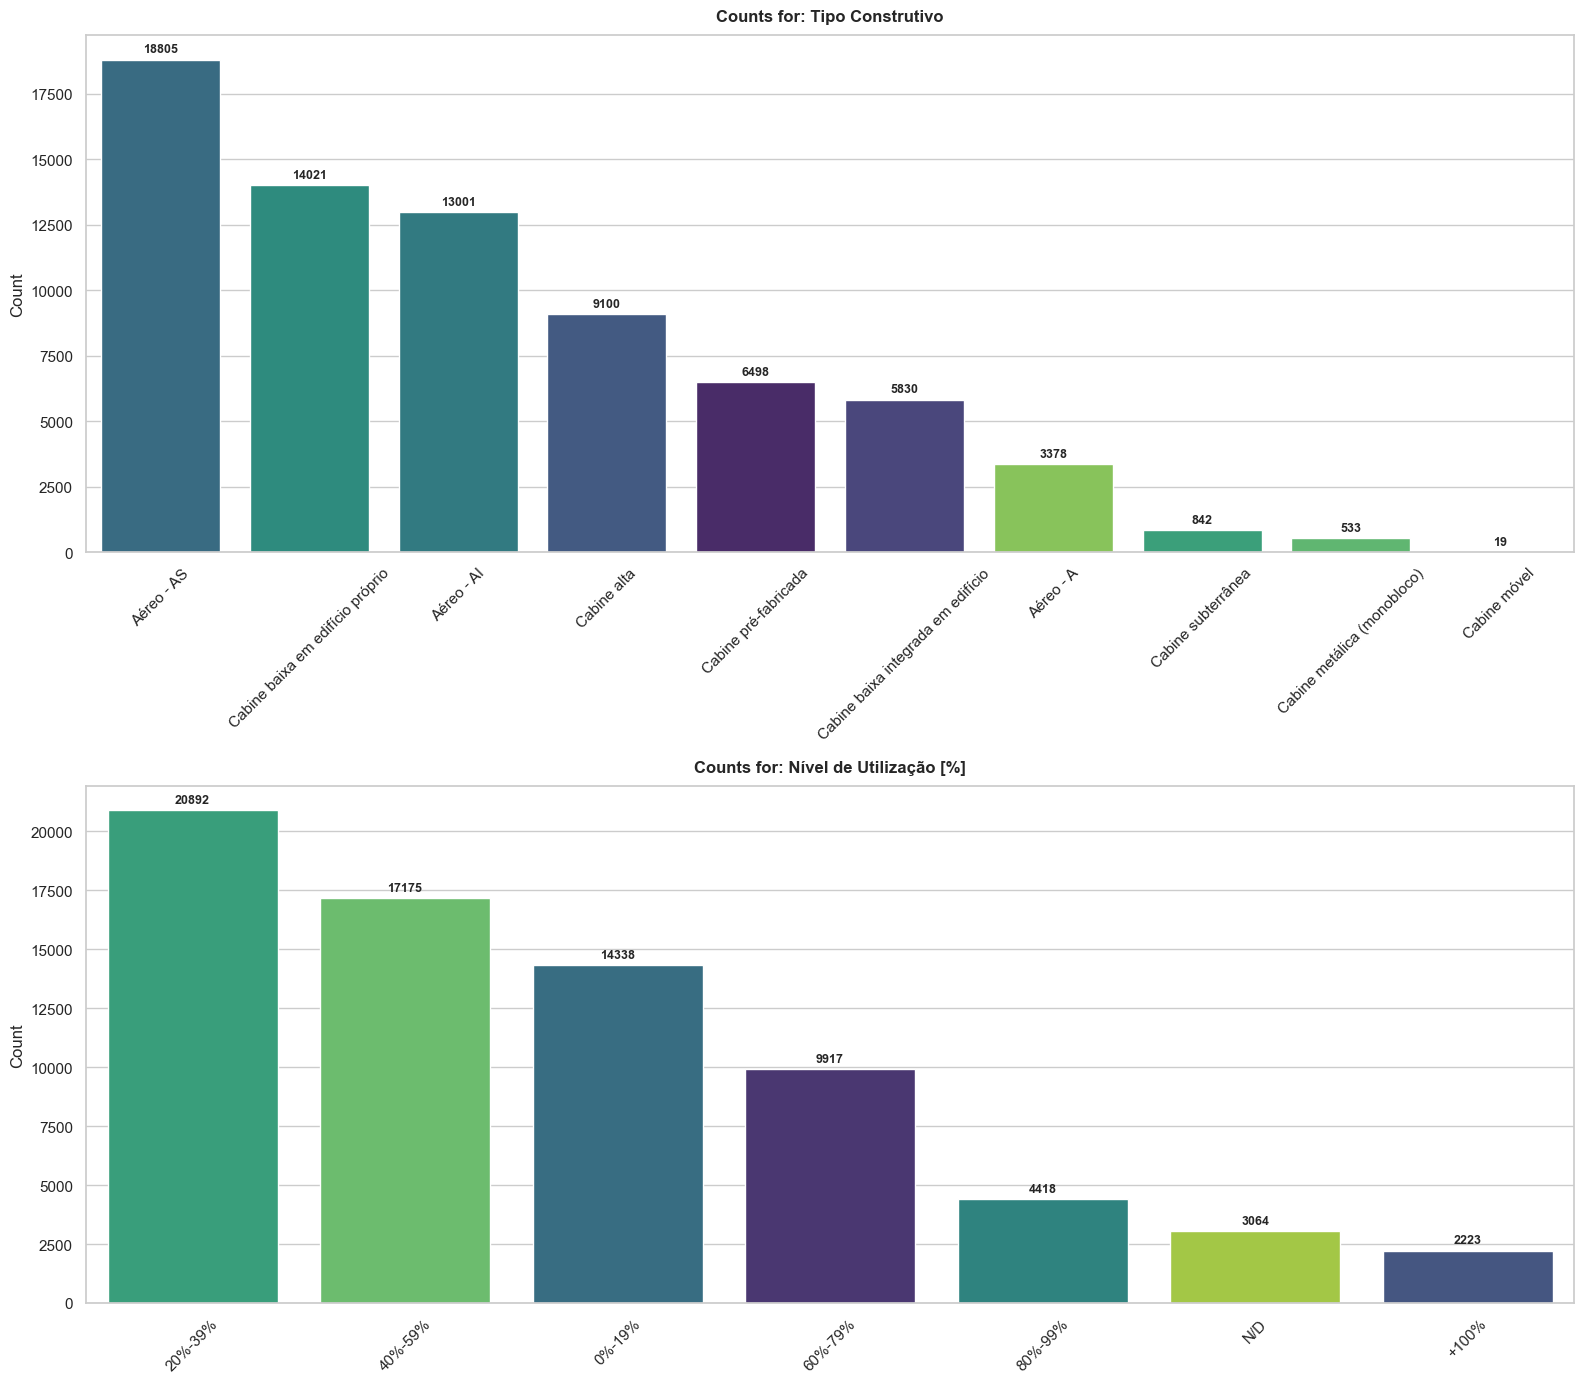

In [12]:
# 1. Filter out columns with > 20 unique values up front
categorical_columns = [
    col
    for col in df.select_dtypes(include=["object", "category"]).columns
    if df[col].nunique() <= 10
]

# 2. Dynamic grid layout calculation
num_cols = len(categorical_columns)
grid_cols = 1  # Adjust this to 3 or 4 if you have many columns
grid_rows = math.ceil(num_cols / grid_cols)

# 3. Create the single figure context
fig, axes = plt.subplots(
    grid_rows, grid_cols, figsize=(16, 14)
)
axes = axes.flatten()  # Flatten to easily loop over them with a single index

sns.set_theme(style="whitegrid")

# 4. Populate the subplots
for i, column in enumerate(categorical_columns):
    ax = axes[i]

    # Create the sorted count plot on the specific subplot axis (ax=ax)
    sns.countplot(
        data=df,
        x=column,
        hue=column,
        order=df[column].value_counts().index,
        palette="viridis",
        legend=False,
        ax=ax,
    )

    # Loop through all containers to label every single bar
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9, weight="bold")

    # Clean up labels per subplot
    ax.set_title(f"Counts for: {column}", fontsize=12, pad=10, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)


# 5. Hide any leftover/empty subplot boxes in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing and display
plt.tight_layout()
plt.show()


In [10]:
df_mapa = (
    df.assign(
        lat_round=df["latitude"].round(2),
        lon_round=df["longitude"].round(2)
    )
    .groupby(["lat_round", "lon_round"])
    .size()
    .reset_index(name="quantidade")
)

fig = px.density_map(
    df_mapa,
    lat="lat_round",
    lon="lon_round",
    z="quantidade",
    radius=20,
    center={"lat": 39.5, "lon": -8.0},
    zoom=5,
    color_continuous_scale="YlOrRd",
)

fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()

###